### Zomato Data Analysis Project

Step 1- import Libraries

In [1]:
!pip install matplotlib
!pip install seaborn

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Step 2 - Create the DataFrame

In [19]:
df = pd.read_csv("Zomato_data.csv")

In [20]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [21]:
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [22]:
df.columns.tolist()

['name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'approx_cost(for two people)',
 'listed_in(type)']

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [24]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


### convert the data type of column - rate

In [25]:
def handleRate(value):
    value = str(value).split('/')
    value = value[0]
    return float (value)

df['rate'] = df['rate'].apply(handleRate)
print(df.head())

                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [27]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0, 0.5, 'Count of Resturant')

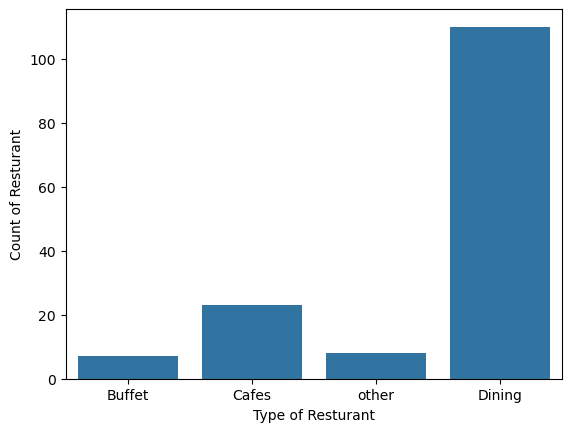

In [29]:
sns.countplot(x = df['listed_in(type)'])
plt.xlabel("Type of Resturant")
plt.ylabel("Count of Resturant")

conclusion : Majority of the Resturnat falls in dinning type.

### Q2 how many  votes has each type of restaurant recived from customers?

In [41]:
group_data = df.groupby('listed_in(type)')['votes'].sum()

result = pd.DataFrame({'votes': group_data})

result

,votes
listed_in(type),
Buffet,3028
Cafes,6434
Dining,20363
other,9367


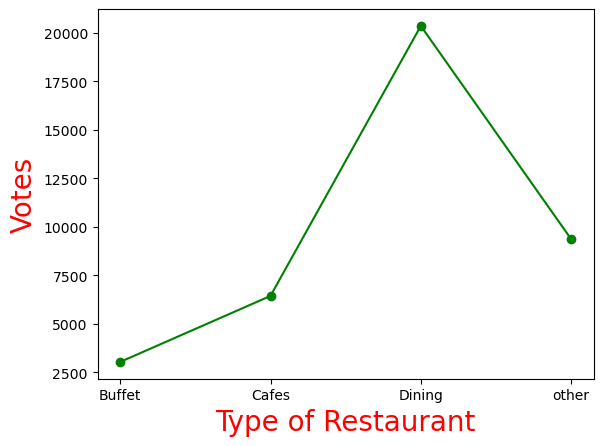

In [39]:
plt.plot(result, color='green', marker='o')

plt.xlabel("Type of Restaurant", color='red', fontsize=20)
plt.ylabel("Votes", color='red', fontsize=20)

plt.show()

- Conclusion : Dinnig resturant has recived max vote

### Q3 What are the rating that the majority of restaurants have recived?

In [42]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


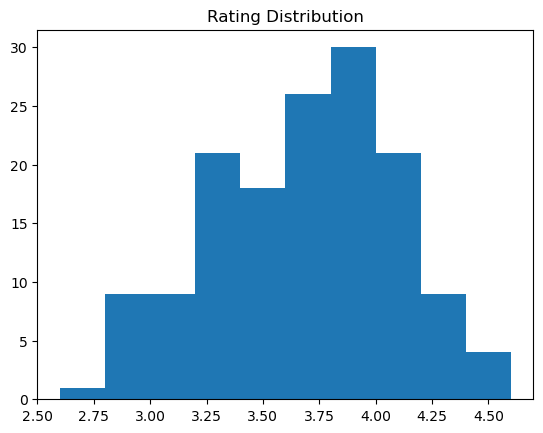

In [48]:
plt.hist(df['rate'], bins = 10)
plt.title("Rating Distribution")
plt.show()

- Conclusion : The Majority resturant received rating from 3.75 to 4

### Q4. Average Order Spending By Couples

In [49]:
 df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

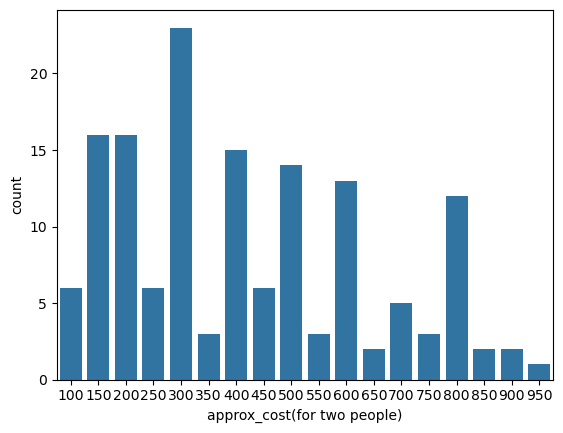

In [50]:
couple_data = df['approx_cost(for two people)']
sns.countplot(x = couple_data)

- Conclusion : The majority of couple prefer resturant with an approximate cost of 300 rupees.

### Q5 Which mode received maximum rating

<Axes: xlabel='online_order', ylabel='rate'>

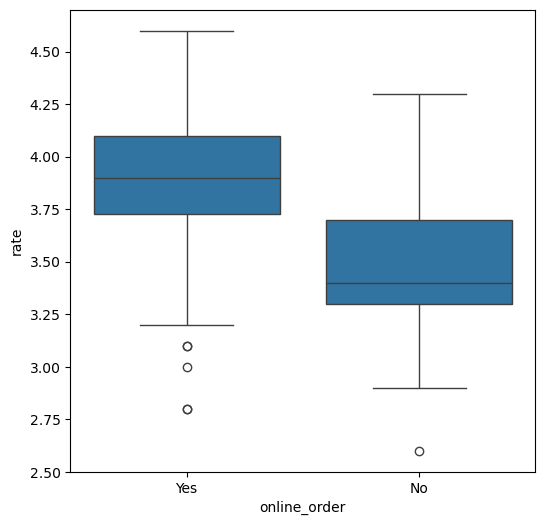

In [56]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order' , y = 'rate', data = df)

Conclusion : Offline order recevied lower rating in comparsion to online orders

### Q6. Which type of restaurant received more offline orders, so thaat omato can provide customers with some good offers.

<function matplotlib.pyplot.show(close=None, block=None)>

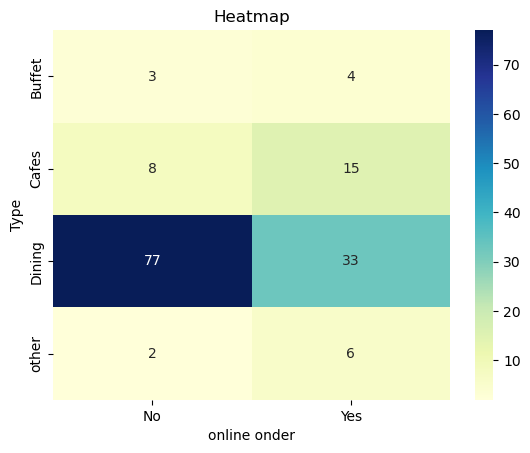

In [61]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns = 'online_order', aggfunc = 'size', fill_value = 0)
sns.heatmap(pivot_table, annot = True, cmap = "YlGnBu", fmt = 'd')
plt.title("Heatmap")
plt.xlabel('online onder')
plt.ylabel('Type')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

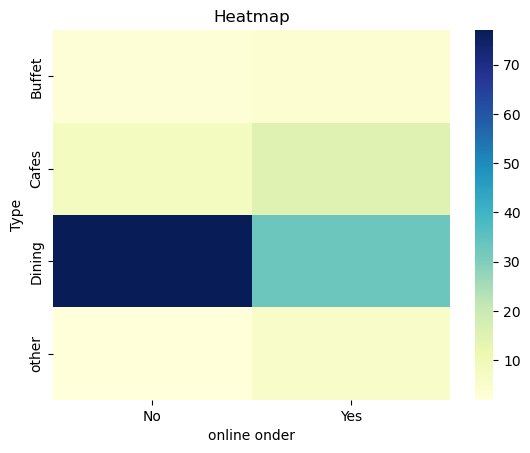

In [63]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns = 'online_order', aggfunc = 'size', fill_value = 0)
sns.heatmap(pivot_table, annot = False, cmap = "YlGnBu", fmt = 'd')
plt.title("Heatmap")
plt.xlabel('online onder')
plt.ylabel('Type')
plt.show

In [62]:
  pivot_table

online_order,No,Yes
listed_in(type),,
Buffet,3,4
Cafes,8,15
Dining,77,33
other,2,6
